Adjusted Rand Index:0.7302382722834697


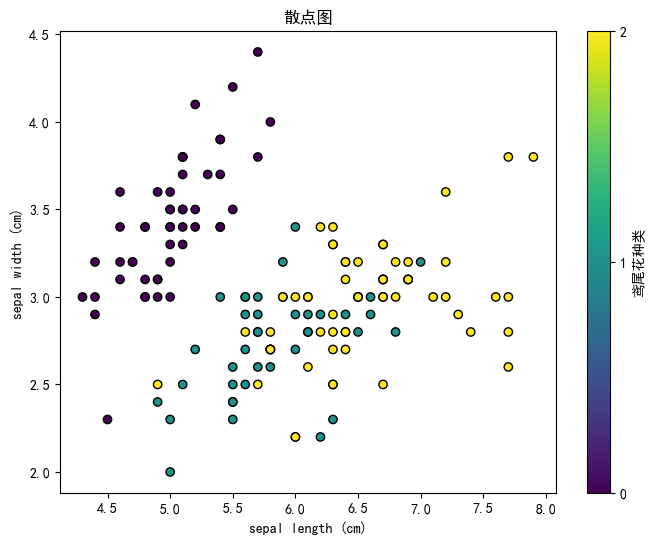

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.metrics import adjusted_rand_score

#先导入数据，再随机选择中心点，接着分成几类，通过重新计算平均值确定新中心点进行训练得出比较好的中心点,再进行预测

class KMeans:
    #初始化
    def __init__(self,data,num_clusters,tol=1e-4):
        self.data=data
        self.num_clusters=num_clusters
        self.tol=tol
        self.centroids=None

    #随机选择中心点
    def centroids_init(self):
        # 总的数据个数
        num_examples=self.data.shape[0]
        # 在num_examples中选取num_clusters个作为中心点，并且不会重复选择
        indices=np.random.choice(num_examples,self.num_clusters,replace=False)
        return self.data[indices]

    # 找到离数据点最近的中心点
    def centroids_find_closest(self,centroids):
        num_examples=self.data.shape[0]
        num_centroids=centroids.shape[0]
        # 初始化closest_centroids_ids 数组，确保最后得到的是相同形式的数据点
        closest_centroids_ids=np.zeros(num_examples,dtype=int)
        # 对每一个数据点分别计算与所有num_centroids的距离
        for example_index in range(num_examples):
            # 初始化距离
            distance=np.zeros(num_centroids)
            #求数据点与所有中心点的距离并得到距离最小的中心点
            for centroid_index in range(num_centroids):
                distance_diff=self.data[example_index,:]-centroids[centroid_index,:]
                distance[centroid_index]=np.sum(distance_diff**2)
            closest_centroids_ids[example_index]=np.argmin(distance)
        return closest_centroids_ids

    # 更新中心点
    def centroids_compute(self,closest_centroids_ids):
        # 数据特征的个数
        num_features=self.data.shape[1]
        # 初始化中心点
        centroids=np.zeros((self.num_clusters,num_features))
        # 对每个类别进行计算求出新的中心点
        for centroid_id in range(self.num_clusters):
            # 找到索引确定是哪一类的数据点
            closest_ids=closest_centroids_ids==centroid_id
            if np.sum(closest_ids)>0:
                centroids[centroid_id]=np.mean(self.data[closest_ids,:],axis=0)
        return centroids

    # 开始训练
    def train(self, max_iterations):
        # 先随机选择中心点
        centroids=self.centroids_init()
        num_examples=self.data.shape[0]
        # 初始化与最近中心点的距离且确保形式一样
        closest_centroids_ids=np.zeros(num_examples, dtype=int)
        # 开始训练求更好的中心点
        for _ in range(max_iterations):
            # 找到与数据点最近的中心点
            closest_centroids_ids=self.centroids_find_closest(centroids)
            # 进行中心点位置更新
            new_centroids=self.centroids_compute(closest_centroids_ids)
            if np.linalg.norm(new_centroids-centroids)<self.tol:
                break
            centroids=new_centroids
        self.centroids=centroids
        return centroids, closest_centroids_ids

    #预测
    def predict(self, X):
        if self.centroids is None:
            self.train(max_iterations=100)
        distances=np.linalg.norm(X[:,np.newaxis]-self.centroids,axis=2)
        return np.argmin(distances,axis=1)

# 加载鸢尾花数据集
iris=load_iris()
#获取数据集
X=iris.data
#获取类别标签
y=iris.target
#进行聚类
kmeans=KMeans(X, num_clusters=3)
centroids,closest_centroids_ids=kmeans.train(max_iterations=100)
labels=kmeans.predict(X)
# 计算调整兰德指数来评估聚类结果
ari=adjusted_rand_score(y,labels)
print(f"Adjusted Rand Index:{ari}")

# 绘制散点图
plt.figure(figsize=(8, 6))
plt.rcParams['font.sans-serif']=['SimHei']
plt.scatter(X[:, 0],X[:, 1],c=y,cmap='viridis',edgecolor='k')
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.title('散点图')
plt.colorbar(ticks=[0, 1, 2],label='鸢尾花种类')
plt.show()